# Data Set information
Calculated all protein single chain ASA by using Freesasa from raw data(downloaded 176,676 PDB structures from Protein Data Bank in March 2021) and stored some information in PDBsingleChain_sasa_csv.csv. 

Calculated all human single ASA length by using Freesasa from raw data(downloaded 23,391 PDB structures from [Alphafold Homo sapiens](https://alphafold.ebi.ac.uk/download)) and stored some information in AlphaFoldHuman_sasa_csv.csv.    

PDBsingleChain_sasa_csv contains 63036 protein single chain structures with 3 attributes.  
AlphaFoldHuman_sasa_csv contains 20516 protein single chain structures with 3 attributes.      
* structure_id: PDB id    
* chain_id: chain id  
* sasa: ASA of a protein single chain structure

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# Getting Data

In [2]:
pdb_df=pd.read_csv("D:/ma/PDB project/data/sasa_db/PDBsingleChain_sasa_csv.csv")
alpha_df=pd.read_csv("D:/ma/PDB project/data/sasa_db/AlphaFoldHuman_sasa_csv.csv")

In [3]:
pdb_df.head(4)

,structure_id,chain_id,sasa
0,101m,A,8180.48
1,102l,A,8498.17
2,102m,A,8138.08
3,103l,A,8303.30


In [4]:
alpha_df.head(4)

,structure_id,chain_id,sasa
0,AF-A0A024R1R8-F1-model_v1,A,7825.99
1,AF-A0A024RBG1-F1-model_v1,A,12653.76
2,AF-A0A024RCN7-F1-model_v1,A,6004.39
3,AF-A0A075B6H5-F1-model_v1,A,9193.46


In [5]:
print('pdb shape:{0}, Alpha shape:{1}'.format(pdb_df.shape,alpha_df.shape))

pdb shape:(63036, 3), Alpha shape:(20628, 3)


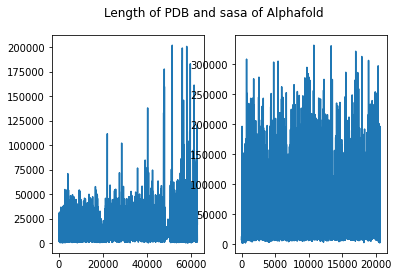

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Sasa of PDB and sasa of Alphafold')
ax1.plot(pdb_df.sasa)
ax2.plot(alpha_df.sasa)

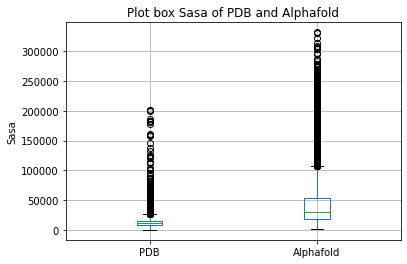

In [11]:
plotBoxTwoElement(pdb_df.sasa,alpha_df.sasa,'PDB','Alphafold','Sasa','Plot box Sasa of PDB and Alphafold')

In [5]:
def removeOutlier(data_df,data):
    q1 = data.quantile(0.25)
    q3  = data.quantile(0.75)

    iqr= np.round(q3-q1,2)
    upper_bound=q3+(1.5*iqr)
    lower_bound=q1-(1.5*iqr)
    pdb_filtered = data_df[(data < upper_bound) & (data > lower_bound)]
    return pdb_filtered

In [6]:
pdb=removeOutlier(pdb_df,pdb_df.sasa)
alpha=removeOutlier(alpha_df,alpha_df.sasa)

In [8]:
def plotBoxTwoElement(data1,data2,y1,y2,x,title):
    data_1=pd.Series(np.array(data1))
    data_2 = pd.Series(np.array(data2))
    data=pd.DataFrame({y1:data_1,y2:data_2})
    data.boxplot()
    plt.ylabel(x)
    plt.title(title)
    plt.show()

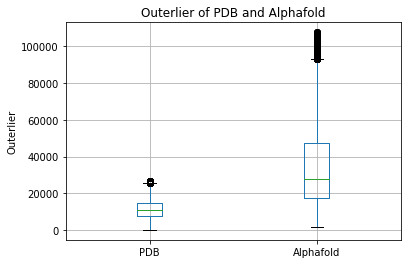

In [10]:
plotBoxTwoElement(pdb.sasa,alpha.sasa,'PDB','Alphafold','Sasa','Plot box Sasa of PDB and Alphafold')

In [19]:
def plotTwoElementRatio(data1,data2,title,featureName):
    #plotBoxLength(data1, data2,'PDB','AlphaFold','Chain length','Distribution of chain length of PDB single chain and AlphaFold human')
    density1, bins1, _ = plt.hist(data1, alpha=0.5, weights=np.ones(len(data1)) / len(data1),label='PDB total:' + str(len(data1)))
    #addRatioOnTop(new_data1, density1, bins1)
    density2, bins2, _ = plt.hist(data2, alpha=0.5, weights=np.ones(len(data2)) / len(data2),label='AlphaFold human total:' + str(len(data2)))
    plt.title(title)
    plt.xlabel(featureName)
    plt.ylabel('Ratio')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
    plt.legend()
    plt.show()

### result
Obviously, the coverage of PDB and Alphafold are different. After around 15,000 ASA, the proportion of Alphafold is much higher than PDB. Alphafold did a really good job in large ASA. They have the different pattern. 

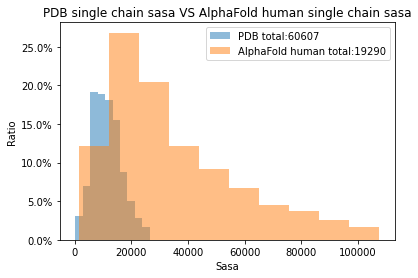

In [31]:
plotTwoElementRatio(pdb['sasa'],alpha['sasa'],"PDB single chain sasa VS AlphaFold human single chain sasa",'Sasa')